# Combine Two YOLO Models on the Same NFL Frame (No Homography Yet)

This notebook:

- Loads **two trained YOLO models**:
  - A *field model* (detects hashes, numbers, etc.)
  - A *player model* (detects players)
- Runs **both models on the same input image**
- Extracts detections from each
- Combines the outputs into a single Python structure

> This version does **not** do any homography / field-coordinate mapping.  
> It only combines raw pixel-space detections.


In [475]:
import os
import sys
from pathlib import Path
from glob import glob

import cv2
import numpy as np
from ultralytics import YOLO

print("Python:", sys.version)
print("CWD:", os.getcwd())

# ========================
# CONFIG: UPDATE THESE PATHS
# ========================

# Path to trained YOLO models
# Make sure these point to your actual best.pt files (usually under runs/train/.../weights/best.pt)
FIELD_MODEL_WEIGHTS = "runs/detect/football_yolo11n2/weights/best.pt"     # field / hash / number model
PLAYER_MODEL_WEIGHTS = "runs/detect/football_positions3/weights/best.pt" # player detector
NUMBER_MODEL_WEIGHTS = "runs/classify/train5/weights/best.pt"

# ========================
# SELECT TEST IMAGE
# ========================

# Path to test images folder
TEST_IMAGES_FOLDER = "data/Football Player Detection.v7i.yolov11/test/images"

# Get all available test images
test_images = sorted(glob(os.path.join(TEST_IMAGES_FOLDER, "*.jpg")))
test_images.extend(sorted(glob(os.path.join(TEST_IMAGES_FOLDER, "*.png"))))

if not test_images:
    raise FileNotFoundError(f"No images found in {TEST_IMAGES_FOLDER}")

# Display available images and prompt for selection
print(f"\n{'='*70}")
print(f"Available test images ({len(test_images)} total):")
print(f"{'='*70}")
for idx, img_path in enumerate(test_images):
    filename = os.path.basename(img_path)
    print(f"  [{idx}] {filename}")
print(f"{'='*70}")

# Interactive popup selection
while True:
    try:
        user_input = input(f"\n👉 Enter image number (0-{len(test_images)-1}) or press Enter for default [0]: ").strip()
        
        if user_input == "":
            SELECTED_IMAGE_INDEX = 0
            break
        
        SELECTED_IMAGE_INDEX = int(user_input)
        
        if 0 <= SELECTED_IMAGE_INDEX < len(test_images):
            break
        else:
            print(f"⚠️ Invalid selection. Please enter a number between 0 and {len(test_images)-1}.")
    except ValueError:
        print(f"⚠️ Invalid input. Please enter a number between 0 and {len(test_images)-1}.")

IMAGE_PATH = test_images[SELECTED_IMAGE_INDEX]
print(f"\n✅ Selected image [{SELECTED_IMAGE_INDEX}]: {os.path.basename(IMAGE_PATH)}")
print(f"   Full path: {IMAGE_PATH}")

print("\nField model weights:", FIELD_MODEL_WEIGHTS)
print("Player model weights:", PLAYER_MODEL_WEIGHTS)
print("Number model weights:", NUMBER_MODEL_WEIGHTS)

Python: 3.9.6 (default, Oct 17 2025, 17:15:53) 
[Clang 17.0.0 (clang-1700.4.4.1)]
CWD: /Users/lucaspedemonte/Documents/Cursor/NFL_Play_Outcome_Classifier

Available test images (9 total):
  [0] 57503_004156_Sideline_frame0643_jpg.rf.0fe4c096792e2cb8fa6a9d0f2e8bdacd.jpg
  [1] 57504_003102_Sideline_frame0736_jpg.rf.4931724229805b9402822829df36efcd.jpg
  [2] 57506_000286_Sideline_frame193_jpg.rf.cd69aa4f300bd4661fbe46509cc25e93.jpg
  [3] 57506_001426_Sideline_frame255_jpg.rf.5af18feaa7363dfdcc895caf062f02ac.jpg
  [4] 57508_003241_Sideline_frame1006_jpg.rf.fb6164480625372ddc480e5452cd8d50.jpg
  [5] 57509_003828_Sideline_frame0852_jpg.rf.35f981f09a1a8111b19160d93a509dc3.jpg
  [6] 57511_000051_Sideline_frame0567_jpg.rf.45f1645df9f25c0cd1ab21742ede10ba.jpg
  [7] 57511_003212_Sideline_frame560_jpg.rf.65af6d1efdc7eab87be054b51e372a47.jpg
  [8] 57512_002838_Sideline_frame59_jpg.rf.a341e3ca674fc7ccf80eb81a74772ca1.jpg

✅ Selected image [8]: 57512_002838_Sideline_frame59_jpg.rf.a341e3ca674fc7ccf80

In [476]:
# ========================
# Load YOLO Models
# ========================

if not os.path.exists(FIELD_MODEL_WEIGHTS):
    print(f"⚠️ Field model weights not found at: {FIELD_MODEL_WEIGHTS}")
else:
    print(f"✅ Found field model at: {FIELD_MODEL_WEIGHTS}")

if not os.path.exists(PLAYER_MODEL_WEIGHTS):
    print(f"⚠️ Player model weights not found at: {PLAYER_MODEL_WEIGHTS}")
else:
    print(f"✅ Found player model at: {PLAYER_MODEL_WEIGHTS}")

if not os.path.exists(NUMBER_MODEL_WEIGHTS):
    print(f"⚠️ Player model weights not found at: {NUMBER_MODEL_WEIGHTS}")
else:
    print(f"✅ Found player model at: {NUMBER_MODEL_WEIGHTS}")

field_model = YOLO(FIELD_MODEL_WEIGHTS)
player_model = YOLO(PLAYER_MODEL_WEIGHTS)
number_model = YOLO(NUMBER_MODEL_WEIGHTS)

print("Field model classes:", field_model.names)
print("Player model classes:", player_model.names)
print("Number model classes:", number_model.names)

✅ Found field model at: runs/detect/football_yolo11n2/weights/best.pt
✅ Found player model at: runs/detect/football_positions3/weights/best.pt
✅ Found player model at: runs/classify/train5/weights/best.pt
Field model classes: {0: 'ball', 1: 'five_hash', 2: 'hash', 3: 'marker', 4: 'number', 5: 'player', 6: 'pylon', 7: 'ref'}
Player model classes: {0: 'C', 1: 'DB', 2: 'LB', 3: 'QB', 4: 'SKILL'}
Number model classes: {0: '10', 1: '20', 2: '30', 3: '40', 4: '50'}


In [477]:
# ========================
# Helper: Convert YOLO Results to Dicts
# ========================

def extract_detections(result):
    """Convert a YOLO result object into a list of simple dicts.
    
    Each dict:
    {
        'class_id': int,
        'class_name': str,
        'confidence': float,
        'bbox': (x1, y1, x2, y2)
    }
    """
    det_list = []
    names = result.names
    
    for box in result.boxes:
        cls_id = int(box.cls[0])
        conf = float(box.conf[0])
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        
        det_list.append({
            "class_id": cls_id,
            "class_name": names[cls_id],
            "confidence": conf,
            "bbox": (x1, y1, x2, y2),
        })
    return det_list

In [478]:
# ========================
# Run All Models on the Same Image
# ========================

# Load the image
img = cv2.imread(IMAGE_PATH)
if img is None:
    raise FileNotFoundError(f"Could not load image at: {IMAGE_PATH}")

# ------------------------
# 1. Run the field model
# ------------------------
print("Running field model...")
field_results = field_model(img)[0]   # first (and only) image in batch
field_dets = extract_detections(field_results)
print(f"Field detections: {len(field_dets)}")

# Add yard-number classification for 'number' detections
for det in field_dets:
    if "number" not in det["class_name"].lower():
        continue

    x1, y1, x2, y2 = map(int, det["bbox"])
    crop_bgr = img[y1:y2, x1:x2]
    if crop_bgr.size == 0:
        continue

    crop_rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)

    # classify with number model
    r = number_model(crop_rgb)[0]
    cls_id = int(r.probs.top1)
    yard_label = number_model.names[cls_id]
    conf = float(r.probs.top1conf)

    # attach prediction to this detection
    det["yard_number_pred"] = yard_label
    det["yard_number_conf"] = conf

# ------------------------
# 2. Run the player model
# ------------------------
print("\nRunning player model...")
player_results = player_model(img)[0]
player_dets = extract_detections(player_results)
print(f"Player detections: {len(player_dets)}")

# ------------------------
# 3. Combine outputs
# ------------------------
combined_output = {
    "field": field_dets,    # now includes yard_number_pred/conf on number boxes
    "players": player_dets,
}

combined_output

Running field model...

0: 736x1280 11 five_hashs, 45 hashs, 2 markers, 6 numbers, 68.2ms
Speed: 1.8ms preprocess, 68.2ms inference, 0.5ms postprocess per image at shape (1, 3, 736, 1280)
Field detections: 64

0: 64x64 20 0.98, 30 0.02, 50 0.00, 10 0.00, 40 0.00, 1.4ms
Speed: 0.4ms preprocess, 1.4ms inference, 0.0ms postprocess per image at shape (1, 3, 64, 64)

0: 64x64 10 0.84, 20 0.13, 30 0.02, 40 0.00, 50 0.00, 1.2ms
Speed: 0.5ms preprocess, 1.2ms inference, 0.0ms postprocess per image at shape (1, 3, 64, 64)

0: 64x64 20 1.00, 30 0.00, 10 0.00, 50 0.00, 40 0.00, 1.3ms
Speed: 0.5ms preprocess, 1.3ms inference, 0.0ms postprocess per image at shape (1, 3, 64, 64)

0: 64x64 10 0.53, 30 0.31, 40 0.10, 50 0.06, 20 0.01, 1.3ms
Speed: 0.5ms preprocess, 1.3ms inference, 0.0ms postprocess per image at shape (1, 3, 64, 64)

0: 64x64 30 1.00, 20 0.00, 50 0.00, 10 0.00, 40 0.00, 1.1ms
Speed: 0.4ms preprocess, 1.1ms inference, 0.0ms postprocess per image at shape (1, 3, 64, 64)

0: 64x64 10 1.0

{'field': [{'class_id': 2,
   'class_name': 'hash',
   'confidence': 0.9267293810844421,
   'bbox': (723.3321533203125,
    244.34329223632812,
    736.6458740234375,
    257.8368835449219)},
  {'class_id': 1,
   'class_name': 'five_hash',
   'confidence': 0.8875434398651123,
   'bbox': (1165.7470703125,
    312.38525390625,
    1192.673828125,
    319.7078857421875)},
  {'class_id': 1,
   'class_name': 'five_hash',
   'confidence': 0.8866279721260071,
   'bbox': (999.22509765625,
    289.9239501953125,
    1024.51220703125,
    297.90008544921875)},
  {'class_id': 3,
   'class_name': 'marker',
   'confidence': 0.8658434152603149,
   'bbox': (92.326171875,
    603.7049560546875,
    122.09774780273438,
    700.5355224609375)},
  {'class_id': 2,
   'class_name': 'hash',
   'confidence': 0.8386999368667603,
   'bbox': (421.409423828125,
    201.78955078125,
    436.71331787109375,
    214.234130859375)},
  {'class_id': 1,
   'class_name': 'five_hash',
   'confidence': 0.8329778909683228,

Combined detections summary:
{'field': [{'bbox': (723.3321533203125,
                     244.34329223632812,
                     736.6458740234375,
                     257.8368835449219),
            'class_id': 2,
            'class_name': 'hash',
            'confidence': 0.9267293810844421},
           {'bbox': (1165.7470703125,
                     312.38525390625,
                     1192.673828125,
                     319.7078857421875),
            'class_id': 1,
            'class_name': 'five_hash',
            'confidence': 0.8875434398651123},
           {'bbox': (999.22509765625,
                     289.9239501953125,
                     1024.51220703125,
                     297.90008544921875),
            'class_id': 1,
            'class_name': 'five_hash',
            'confidence': 0.8866279721260071},
           {'bbox': (92.326171875,
                     603.7049560546875,
                     122.09774780273438,
                     700.5355224609375),
     

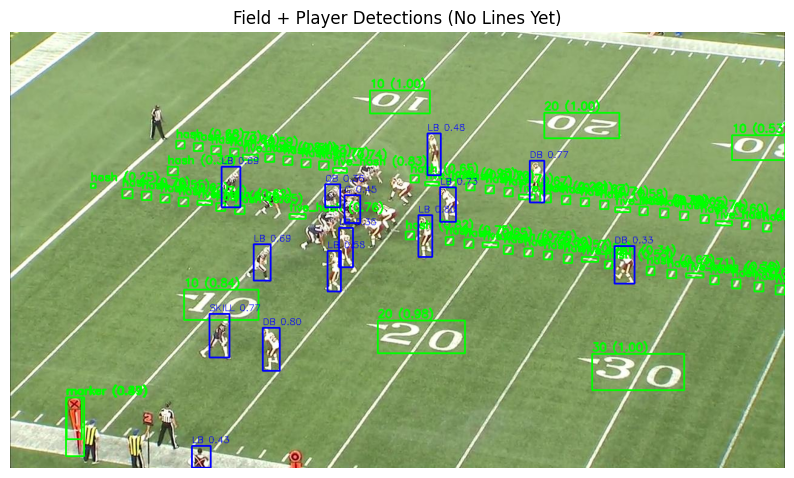

In [479]:
# ========================
# Pretty Print & Visualize Detections (NO NUMBER–HASH LINES)
# ========================
from pprint import pprint
import matplotlib.pyplot as plt
import cv2

print("Combined detections summary:")
pprint(combined_output)

vis = img.copy()

# ---- 1. Draw field detections ----
for det in combined_output["field"]:
    x1, y1, x2, y2 = map(int, det["bbox"])

    if "number" in det["class_name"].lower() and "yard_number_pred" in det:
        label = f"{det['yard_number_pred']} ({det['yard_number_conf']:.2f})"
    else:
        label = f"{det['class_name']} ({det['confidence']:.2f})"

    cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(
        vis,
        label,
        (x1, max(0, y1 - 5)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (0, 255, 0),
        2
    )

# ---- 2. Draw player detections ----
for det in combined_output["players"]:
    x1, y1, x2, y2 = map(int, det["bbox"])
    label = f"{det['class_name']} {det['confidence']:.2f}"
    cv2.rectangle(vis, (x1, y1), (x2, y2), (255, 0, 0), 2)
    cv2.putText(
        vis,
        label,
        (x1, max(y1 - 5, 0)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (255, 0, 0),
        1
    )

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Field + Player Detections (No Lines Yet)")
plt.show()

🔍 Analyzing 6 number detections across 3 yard line types...

📊 All detected numbers:
   Yard 20: conf=0.997, center=(944.4, 154.7)
   Yard 20: conf=0.978, center=(679.1, 503.6)
   Yard 10: conf=0.998, center=(644.1, 115.4)
   Yard 10: conf=0.842, center=(348.9, 450.6)
   Yard 10: conf=0.529, center=(1236.1, 191.1)
   Yard 30: conf=1.000, center=(1037.4, 561.3)

   Checking yard line '20': 2 detection(s)
      ✅ MANDATORY pair found: conf=1.00 & 0.98, dx=265.3, dy=349.0 (LINE GOES UP)

   Checking yard line '10': 3 detection(s)
      ✅ MANDATORY pair found: conf=1.00 & 0.84, dx=295.3, dy=335.3 (LINE GOES UP)

✅ FINAL RESULTS: Found 2 valid yard number pair(s):
   📌 2 MANDATORY pair(s) (both numbers >= 70% confidence) - ALWAYS INCLUDED
   📋 0 optional pair(s) (both numbers >= 60% confidence)

   🔴 [0] Yard line 20: MANDATORY - confidence=1.98 (near=0.98, far=1.00)
   🔴 [1] Yard line 10: MANDATORY - confidence=1.84 (near=0.84, far=1.00)
Found 0 hash lanes.
Found 2 hash rows.


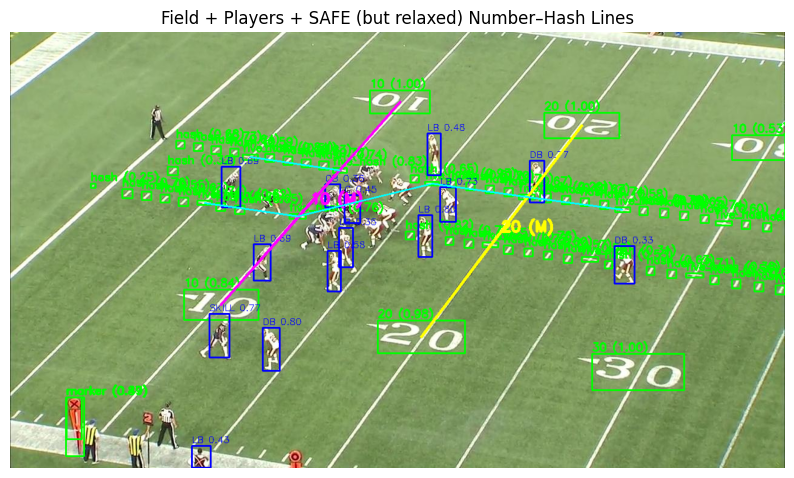

In [480]:
# ========================
# Draw Number–Hash Lines (with relaxed rules)
# ========================
import math
from collections import defaultdict

vis2 = vis.copy()
field_dets = combined_output["field"]

# Extract number & five-hash detections
number_dets = [
    d for d in field_dets
    if "number" in d["class_name"].lower() and "yard_number_pred" in d
]

five_hash_dets = [
    d for d in field_dets
    if "five_hash" in d["class_name"].lower()
]

def bbox_center(det):
    x1, y1, x2, y2 = det["bbox"]
    return 0.5 * (x1 + x2), 0.5 * (y1 + y2)

for d in number_dets:
    d["center"] = bbox_center(d)

for d in five_hash_dets:
    d["center"] = bbox_center(d)

# Group by predicted yard number
# Include all numbers for now - we'll filter by confidence when pairing
numbers_by_label = defaultdict(list)
for d in number_dets:
    numbers_by_label[d["yard_number_pred"]].append(d)

# Geometry thresholds - more lenient for high-confidence pairs
MAX_X_DIFF_SAME_YARD_NORMAL = 120   # Max horizontal difference for normal pairs
MAX_X_DIFF_SAME_YARD_HIGH_CONF = 200  # More lenient for high-confidence pairs
MIN_Y_DIFF_SAME_YARD_NORMAL = 50    # Min vertical difference for normal pairs  
MIN_Y_DIFF_SAME_YARD_HIGH_CONF = 30  # More lenient for high-confidence pairs
MAX_HASH_X_OFFSET = 80
MAX_HASH_Y_MARGIN = 60

# Confidence thresholds
MANDATORY_CONF_THRESH = 0.70  # Both numbers must be >= 70% for mandatory pairs
OPTIONAL_CONF_THRESH = 0.60   # Lower threshold for optional pairs

used_hashes = set()

# ========================
# Find ALL valid opposite-side number pairs (multiple ground truth lines)
# MANDATORY: Pairs where BOTH numbers have >= 70% confidence MUST be included
# Use more lenient geometry checks for high-confidence pairs
# ========================

mandatory_pairs = []  # Pairs where both numbers >= 70% confidence
optional_pairs = []    # Other valid pairs
rejected_pairs = []    # For debugging - pairs that were rejected

print(f"🔍 Analyzing {sum(len(dets) for dets in numbers_by_label.values())} number detections across {len(numbers_by_label)} yard line types...")
print("\n📊 All detected numbers:")
for label, dets in numbers_by_label.items():
    dets_sorted = sorted(dets, key=lambda d: d["yard_number_conf"], reverse=True)
    for det in dets_sorted:
        cx, cy = det["center"]
        print(f"   Yard {label}: conf={det['yard_number_conf']:.3f}, center=({cx:.1f}, {cy:.1f})")

for label, dets in numbers_by_label.items():
    if len(dets) < 2:
        continue

    print(f"\n   Checking yard line '{label}': {len(dets)} detection(s)")
    
    # sort by confidence (highest first)
    dets_sorted = sorted(dets, key=lambda d: d["yard_number_conf"], reverse=True)

    # Try all combinations of detections for this label
    for i in range(len(dets_sorted)):
        for j in range(i + 1, len(dets_sorted)):
            d1, d2 = dets_sorted[i], dets_sorted[j]
            cx1, cy1 = d1["center"]
            cx2, cy2 = d2["center"]

            dx = abs(cx1 - cx2)
            dy = abs(cy1 - cy2)

            conf1 = d1["yard_number_conf"]
            conf2 = d2["yard_number_conf"]
            
            # CRITICAL: If both numbers have >= 70% confidence, ALWAYS include them
            # BUT: Still check that they're across from each other (not horizontal)
            is_mandatory = conf1 >= MANDATORY_CONF_THRESH and conf2 >= MANDATORY_CONF_THRESH
            
            if is_mandatory:
                # MANDATORY pair - check geometry to ensure line goes UP (vertical), not sideways (horizontal)
                # If dy > dx, line goes up (good - across from each other)
                # If dx > dy, line goes sideways (bad - same side of field)
                # Only reject if line is clearly horizontal (dx significantly larger than dy)
                
                if dx > dy * 1.5:  # Line is more horizontal than vertical (dx > 1.5 * dy)
                    rejected_pairs.append((label, conf1, conf2, f"MANDATORY: horizontal line (dx={dx:.1f} > 1.5*dy={dy:.1f})"))
                    print(f"      ⚠️ MANDATORY pair rejected (sideways line): conf={conf1:.2f} & {conf2:.2f}, dx={dx:.1f}, dy={dy:.1f}")
                    continue
                
                # Geometry is valid - line goes up (vertical or mostly vertical)
                score = conf1 + conf2
                
                # assign near (bottom) vs far (top)
                if cy1 > cy2:
                    near_det, far_det = d1, d2
                else:
                    near_det, far_det = d2, d1
                
                mandatory_pairs.append((label, near_det, far_det, score))
                print(f"      ✅ MANDATORY pair found: conf={conf1:.2f} & {conf2:.2f}, dx={dx:.1f}, dy={dy:.1f} (LINE GOES UP)")
            elif conf1 >= OPTIONAL_CONF_THRESH and conf2 >= OPTIONAL_CONF_THRESH:
                # Optional pair - check geometry: line should go UP, not sideways
                if dx > dy * 1.5:  # Line is more horizontal than vertical
                    rejected_pairs.append((label, conf1, conf2, f"horizontal line (dx={dx:.1f} > 1.5*dy={dy:.1f})"))
                    continue
                
                # Geometry is valid - line goes up
                score = conf1 + conf2
                
                # assign near (bottom) vs far (top)
                if cy1 > cy2:
                    near_det, far_det = d1, d2
                else:
                    near_det, far_det = d2, d1
                
                optional_pairs.append((label, near_det, far_det, score))
                print(f"      ✓ Optional pair found: conf={conf1:.2f} & {conf2:.2f}, dx={dx:.1f}, dy={dy:.1f}")

# Print rejected pairs for debugging (optional pairs only - mandatory pairs are never rejected)
if rejected_pairs:
    print(f"\n⚠️ {len(rejected_pairs)} optional pair(s) were rejected due to geometry:")
    for label, conf1, conf2, reason in rejected_pairs:
        print(f"   Yard line {label}: conf={conf1:.2f} & {conf2:.2f} - {reason}")

# Combine: mandatory pairs first (sorted by score), then optional pairs
mandatory_pairs.sort(key=lambda x: x[3], reverse=True)
optional_pairs.sort(key=lambda x: x[3], reverse=True)
valid_pairs = mandatory_pairs + optional_pairs

# If no valid pair, abort gracefully
if len(valid_pairs) == 0:
    print("⚠️ No valid opposite number pair found.")
    best_pair = None
else:
    print(f"\n{'='*70}")
    print(f"✅ FINAL RESULTS: Found {len(valid_pairs)} valid yard number pair(s):")
    print(f"   📌 {len(mandatory_pairs)} MANDATORY pair(s) (both numbers >= 70% confidence) - ALWAYS INCLUDED")
    print(f"   📋 {len(optional_pairs)} optional pair(s) (both numbers >= 60% confidence)")
    print(f"{'='*70}\n")
    
    # Print mandatory pairs first
    idx = 0
    for label, near_det, far_det, score in mandatory_pairs:
        print(f"   🔴 [{idx}] Yard line {label}: MANDATORY - confidence={score:.2f} (near={near_det['yard_number_conf']:.2f}, far={far_det['yard_number_conf']:.2f})")
        idx += 1
    
    # Print optional pairs
    for label, near_det, far_det, score in optional_pairs:
        print(f"   ⚪ [{idx}] Yard line {label}: optional - confidence={score:.2f} (near={near_det['yard_number_conf']:.2f}, far={far_det['yard_number_conf']:.2f})")
        idx += 1
    
    # Store best_pair for backward compatibility (highest scoring pair)
    best_pair = (valid_pairs[0][0], valid_pairs[0][1], valid_pairs[0][2])
    
    # Draw ALL valid pairs - mandatory pairs get thicker lines and brighter colors
    # Colors: bright colors for mandatory, muted for optional
    mandatory_colors = [(0, 255, 255), (255, 0, 255), (255, 255, 0), (0, 255, 0)]  # Cyan, Magenta, Yellow, Green
    optional_colors = [(128, 128, 128), (128, 128, 255), (255, 128, 128), (128, 255, 128)]  # Gray, light blue, light red, light green
    
    idx = 0
    # Draw mandatory pairs first (thicker, brighter)
    for label, near_det, far_det, score in mandatory_pairs:
        cx1, cy1 = near_det["center"]
        cx2, cy2 = far_det["center"]

        p1 = (int(cx1), int(cy1))
        p2 = (int(cx2), int(cy2))

        color = mandatory_colors[idx % len(mandatory_colors)]
        thickness = 4  # Thick lines for mandatory pairs
        
        # Draw the line
        cv2.line(vis2, p1, p2, color, thickness)
        
        # Add label with background for visibility
        mid_x = int(0.5 * (cx1 + cx2))
        mid_y = int(0.5 * (cy1 + cy2))
        label_text = f"{label} (M)"
        cv2.putText(vis2, label_text, (mid_x, mid_y), 
                   cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 3)
        
        # Try to add one hash in-between
        avg_x = 0.5 * (cx1 + cx2)
        y_min, y_max = sorted([cy1, cy2])
        candidates = []
        for h_idx, h in enumerate(five_hash_dets):
            cxh, cyh = h["center"]
            if abs(cxh - avg_x) > MAX_HASH_X_OFFSET:
                continue
            if not (y_min - MAX_HASH_Y_MARGIN <= cyh <= y_max + MAX_HASH_Y_MARGIN):
                continue
            dist = math.hypot(cxh - avg_x, cyh - (0.5 * (y_min + y_max)))
            candidates.append((dist, h_idx, h))
        if candidates:
            _, h_idx, h = sorted(candidates, key=lambda t: t[0])[0]
            cxh, cyh = h["center"]
            ph = (int(cxh), int(cyh))
            cv2.line(vis2, p1, ph, color, 2)
            cv2.line(vis2, ph, p2, color, 2)
        
        idx += 1
    
    # Draw optional pairs (thinner, muted colors)
    opt_idx = 0
    for label, near_det, far_det, score in optional_pairs:
        cx1, cy1 = near_det["center"]
        cx2, cy2 = far_det["center"]

        p1 = (int(cx1), int(cy1))
        p2 = (int(cx2), int(cy2))

        color = optional_colors[opt_idx % len(optional_colors)]
        thickness = 2  # Thinner lines for optional pairs
        
        # Draw the line
        cv2.line(vis2, p1, p2, color, thickness)
        
        # Add label
        mid_x = int(0.5 * (cx1 + cx2))
        mid_y = int(0.5 * (cy1 + cy2))
        cv2.putText(vis2, f"{label}", (mid_x, mid_y), 
                   cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
        
        opt_idx += 1
        idx += 1

        # Now try to add one hash in-between (same logic as before)
        avg_x = 0.5 * (cx1 + cx2)
        y_min, y_max = sorted([cy1, cy2])

        candidates = []
        for h_idx, h in enumerate(five_hash_dets):
            cxh, cyh = h["center"]

            if abs(cxh - avg_x) > MAX_HASH_X_OFFSET:
                continue
            if not (y_min - MAX_HASH_Y_MARGIN <= cyh <= y_max + MAX_HASH_Y_MARGIN):
                continue

            dist = math.hypot(cxh - avg_x, cyh - (0.5 * (y_min + y_max)))
            candidates.append((dist, h_idx, h))

        if candidates:
            _, h_idx, h = sorted(candidates, key=lambda t: t[0])[0]
            cxh, cyh = h["center"]
            ph = (int(cxh), int(cyh))

            cv2.line(vis2, p1, ph, color, 1)
            cv2.line(vis2, ph, p2, color, 1)

# ================================
# Draw hash "grid": vertical lanes + horizontal connections
# ================================

# ================================
# Draw hash "grid": vertical lanes + horizontal connections
# ================================

# Tuneable thresholds
HASH_CONF_THRESH = 0.4        # minimum confidence for hash to use
HASH_LANE_X_THRESH = 60       # max x distance to stay in same lane
HASH_LANE_MIN_Y_SPAN = 80     # min vertical span to draw a vertical lane
HASH_PAIR_Y_MATCH = 30        # max y difference to consider two hashes same row

# Filter hashes by confidence (optional but usually helpful)
usable_hashes = [h for h in five_hash_dets if h.get("confidence", 1.0) >= HASH_CONF_THRESH]
if len(usable_hashes) < 2:
    print("Not enough confident hash detections to draw hash grid.")
else:
    # ---- GLOBAL hash span in X: we'll draw horizontals across this full range ----
    hash_xs = [h["center"][0] for h in usable_hashes]
    global_min_x = min(hash_xs)
    global_max_x = max(hash_xs)

    # ---- 1. Cluster hashes into vertical lanes (left hash / right hash) by x ----
    usable_hashes_sorted = sorted(usable_hashes, key=lambda d: d["center"][0])

    lanes = []
    current_lane = [usable_hashes_sorted[0]]

    for h1, h2 in zip(usable_hashes_sorted, usable_hashes_sorted[1:]):
        x1 = h1["center"][0]
        x2 = h2["center"][0]
        if abs(x1 - x2) < HASH_LANE_X_THRESH:
            current_lane.append(h2)
        else:
            lanes.append(current_lane)
            current_lane = [h2]
    lanes.append(current_lane)

    # Only keep lanes with at least 2 points
    lanes = [lane for lane in lanes if len(lane) >= 2]

    print(f"Found {len(lanes)} hash lanes.")

    # ---- 2. Draw vertical lines down each hash lane ----
    for lane in lanes:
        # sort by y (top to bottom)
        lane_sorted = sorted(lane, key=lambda d: d["center"][1])
        top_h = lane_sorted[0]
        bot_h = lane_sorted[-1]

        cx1, cy1 = top_h["center"]
        cx2, cy2 = bot_h["center"]

        y_span = abs(cy2 - cy1)
        x_span = abs(cx2 - cx1)

        if y_span < HASH_LANE_MIN_Y_SPAN:
            continue  # too short, probably noise

        # We expect hash lanes to be mostly vertical
        if x_span > HASH_LANE_X_THRESH * 2:
            continue

        p_top = (int(cx1), int(cy1))
        p_bot = (int(cx2), int(cy2))

        # yellow vertical lane line
        cv2.line(vis2, p_top, p_bot, (0, 255, 255), 3)

        # ---- 3. Draw slanted polylines through ALL hashes in each row ----

    # 3a. Cluster all usable hashes into horizontal "rows" based on y
    all_hashes_sorted_by_y = sorted(usable_hashes, key=lambda d: d["center"][1])

    rows = []
    for h in all_hashes_sorted_by_y:
        y = h["center"][1]
        placed = False

        for row in rows:
            # Use the average y of the row as its representative height
            row_y = sum(r["center"][1] for r in row) / len(row)
            if abs(y - row_y) <= HASH_PAIR_Y_MATCH:
                row.append(h)
                placed = True
                break

        if not placed:
            rows.append([h])

    # Keep only rows that have at least 2 hashes
    rows = [row for row in rows if len(row) >= 2]

    print(f"Found {len(rows)} hash rows.")

    # 3b. For each row, connect all hashes from left to right
    for row in rows:
        row_sorted = sorted(row, key=lambda d: d["center"][0])

        for h1, h2 in zip(row_sorted, row_sorted[1:]):
            x1, y1 = h1["center"]
            x2, y2 = h2["center"]

            p1 = (int(x1), int(y1))
            p2 = (int(x2), int(y2))

            # cyan line segment through adjacent hashes
            cv2.line(vis2, p1, p2, (255, 255, 0), 2)

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(vis2, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Field + Players + SAFE (but relaxed) Number–Hash Lines")
plt.show()

✓ Baseline: 20 yard line
✓ Across-field: 14.96 pixels/yard
✓ Five_hash positions along field (relative to baseline): ['-465.7', '-450.9', '-329.9', '-320.4', '-185.7', '-48.5', '-47.9', '91.0', '97.3', '237.6', '250.9']
  Skipping small spacing: 14.8 px (likely same yard line)
  Skipping small spacing: 9.6 px (likely same yard line)
  Skipping small spacing: 0.6 px (likely same yard line)
  Skipping small spacing: 6.3 px (likely same yard line)
  Skipping small spacing: 13.3 px (likely same yard line)
✓ Found 11 five-yard hash marks
✓ Valid spacings between different yard lines (pixels): ['121.0', '134.7', '137.2', '138.9', '140.3']
✓ Using spacing: 137.24 pixels for 5 yards
✓ Calculated: 27.45 pixels/yard
✓ Final along-field calibration: 27.45 pixels/yard
✓ Image dimensions: 1280 x 720 pixels
✓ Near hash marks: img_y=363.3 px → field Y = 18.5 yards
✓ Far hash marks: img_y=272.5 px → field Y = 33.8 yards
✓ Baseline center: (836.3, 374.4)
✓ Using 4 reference points for Y calibration:
  

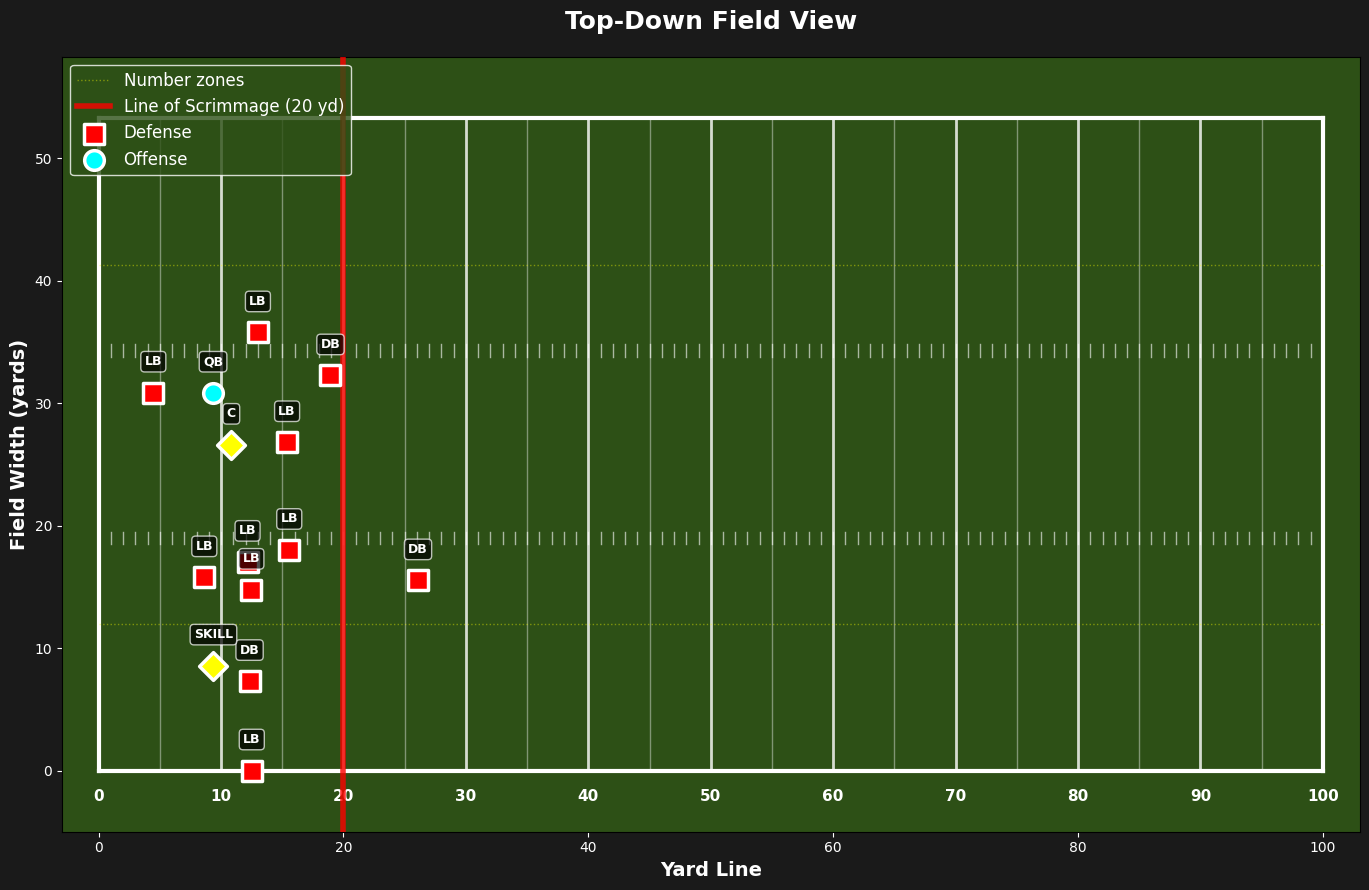


✓ TRANSFORMATION COMPLETE


In [481]:
import numpy as np

# ============================================================================
# SIMPLIFIED COORDINATE TRANSFORMATION
# Uses baseline yard numbers and hash rows to map pixel -> field coordinates
# ============================================================================

# -----------------------------
# 0. Extract baseline information from Cell 6
# -----------------------------
# Check if best_pair exists from Cell 6, or if variables are already defined
if 'best_pair' in globals() and best_pair is not None:
    # Extract from best_pair if it exists
    label_str, near_det, far_det = best_pair
    baseline_label = int(label_str)  # Convert string label (e.g., "50") to int
elif 'label' in globals() and 'near_det' in globals() and 'far_det' in globals():
    # Use variables already defined in Cell 6
    baseline_label = int(label)  # Convert string label to int
else:
    raise RuntimeError("No valid baseline pair found. Please run Cell 6 first and ensure a valid pair was detected.")

# -----------------------------
# 1. Baseline Setup (Yard Numbers)
# -----------------------------
# Inputs from your selection:
# - baseline_label: int (e.g., 40, 50, etc.)
# - near_det: dict with "center" key [x, y] (near sideline number)
# - far_det: dict with "center" key [x, y] (far sideline number)

p_near = np.array(near_det["center"], dtype=np.float32)
p_far = np.array(far_det["center"], dtype=np.float32)

# Vector across field (from near to far sideline)
v_across = p_far - p_near
across_len = np.linalg.norm(v_across)
v_across_unit = v_across / (across_len + 1e-6)

# Physical calibration: numbers are 12 yards from each sideline
FIELD_WIDTH = 53.3
NUM_OFFSET = 12.0
physical_span = FIELD_WIDTH - 2.0 * NUM_OFFSET  # 29.3 yards
pixels_per_yard_across = across_len / physical_span

# Perpendicular direction (along field, perpendicular to baseline)
# Rotate v_across by 90 degrees
v_along_unit = np.array([-v_across_unit[1], v_across_unit[0]])

print(f"✓ Baseline: {baseline_label} yard line")
print(f"✓ Across-field: {pixels_per_yard_across:.2f} pixels/yard")


# -----------------------------
# 2. Five-Yard Hash Calibration (Along-Field Axis)
# -----------------------------
# Five-yard hash marks are spaced exactly 5 yards apart along the field
# This is the most reliable way to calibrate the along-field spacing

# Get five_hash detections from Cell 6 (they should have "center" key)
if 'five_hash_dets' not in globals() or len(five_hash_dets) < 2:
    raise RuntimeError("Need at least 2 five-yard hash marks for calibration. Please run Cell 6 first.")

# Convert to numpy arrays with centers
five_hash_centers = []
for h in five_hash_dets:
    if "center" in h:
        center = np.array(h["center"], dtype=np.float32)
        five_hash_centers.append(center)

if len(five_hash_centers) < 2:
    raise RuntimeError(f"Only found {len(five_hash_centers)} five-yard hash marks with centers. Need at least 2.")

# Project all five_hash centers onto the along-field direction to get their positions
five_hash_positions_along = []
for center in five_hash_centers:
    # Position relative to baseline center, projected onto along-field direction
    delta = center - baseline_center
    pos_along = np.dot(delta, v_along_unit)
    five_hash_positions_along.append((pos_along, center))

# Sort by position along field
five_hash_positions_along.sort(key=lambda x: x[0])

print(f"✓ Five_hash positions along field (relative to baseline): {[f'{p[0]:.1f}' for p in five_hash_positions_along]}")

# Calculate spacing between consecutive five_hash marks
# These should be 5 yards apart (or 10 yards if one is missing)
# BUT: we need to be careful - hash marks on the same yard line (left/right) will have
# very small spacing. We want spacing between hash marks on DIFFERENT yard lines.
five_hash_spacings = []
for i in range(len(five_hash_positions_along) - 1):
    vec = five_hash_positions_along[i+1][1] - five_hash_positions_along[i][1]
    # Project onto along-field direction
    spacing_along = np.dot(vec, v_along_unit)
    spacing_abs = abs(spacing_along)
    
    # Only consider spacings that are significant (likely different yard lines)
    # Hash marks on same yard line will have very small spacing
    if spacing_abs > 20:  # Threshold: at least 20 pixels apart
        five_hash_spacings.append(spacing_abs)
    else:
        print(f"  Skipping small spacing: {spacing_abs:.1f} px (likely same yard line)")

if five_hash_spacings and len(five_hash_spacings) > 0:
    # Print all spacings for debugging
    print(f"✓ Found {len(five_hash_centers)} five-yard hash marks")
    print(f"✓ Valid spacings between different yard lines (pixels): {[f'{s:.1f}' for s in five_hash_spacings]}")
    
    # Use median to be robust to outliers
    median_spacing_pixels = np.median(five_hash_spacings)
    
    # Check if spacing seems reasonable
    if median_spacing_pixels < 30:
        print(f"⚠️ Warning: Median spacing ({median_spacing_pixels:.2f} px) seems small for 5 yards!")
        print(f"   This might indicate calibration issue or hash marks are too close")
        # Try using the maximum spacing instead (might be 10 yards = 2 * 5 yards)
        max_spacing = max(five_hash_spacings)
        if max_spacing > median_spacing_pixels * 1.8:
            print(f"   Using max spacing ({max_spacing:.2f} px) which might represent 10 yards")
            pixels_per_yard_along = max_spacing / 10.0
        else:
            # Still use median but warn
            pixels_per_yard_along = median_spacing_pixels / 5.0
            print(f"   Using median spacing, but result may be inaccurate")
    else:
        # Five-yard hash marks are 5 yards apart
        # So: pixels_per_yard = median_spacing_pixels / 5
        pixels_per_yard_along = median_spacing_pixels / 5.0
    
    print(f"✓ Using spacing: {median_spacing_pixels:.2f} pixels for 5 yards")
    print(f"✓ Calculated: {pixels_per_yard_along:.2f} pixels/yard")
else:
    # Fallback: estimate from baseline width
    print("⚠️ Could not find valid spacings between different yard lines!")
    print("   This might mean all five_hash marks are on the same yard line.")
    print("   Using fallback estimate from baseline width.")
    pixels_per_yard_along = pixels_per_yard_across
    print(f"   Fallback: {pixels_per_yard_along:.2f} pixels/yard (may be inaccurate)")

print(f"✓ Final along-field calibration: {pixels_per_yard_along:.2f} pixels/yard")


# -----------------------------
# 3. Coordinate System Origin & Yard Number Reference Points
# -----------------------------
# CRITICAL: Use yard number positions as anchors for Y coordinate mapping
# Numbers are at 12 yards from each sideline - use them as reference points!

# Get image dimensions
img_h, img_w = img.shape[:2]
print(f"✓ Image dimensions: {img_w} x {img_h} pixels")

# Get yard number positions from valid pairs
if 'valid_pairs' not in globals() or len(valid_pairs) == 0:
    raise RuntimeError("No valid pairs found. Please run Cell 6 first.")

# Collect yard number Y coordinates in IMAGE SPACE (not projected)
# Image Y=0 is top, Y=img_h is bottom
# Field Y=0 is near sideline (bottom of image), Y=53.3 is far sideline (top of image)
near_number_img_y_list = []  # Image Y coordinates of near sideline numbers
far_number_img_y_list = []   # Image Y coordinates of far sideline numbers

for label_str, near_det, far_det, score in valid_pairs:
    # Get actual image Y coordinates (cy is the Y coordinate in image space)
    near_cy = near_det["center"][1]  # Y coordinate in image
    far_cy = far_det["center"][1]    # Y coordinate in image
    
    # Determine which is near (bottom) vs far (top) based on image Y
    # In image: larger Y = bottom (near sideline), smaller Y = top (far sideline)
    if near_cy > far_cy:
        # near_det is actually the bottom one (near sideline)
        near_number_img_y_list.append(near_cy)
        far_number_img_y_list.append(far_cy)
    else:
        # far_det is actually the bottom one (near sideline)
        near_number_img_y_list.append(far_cy)
        far_number_img_y_list.append(near_cy)

# Use median for robustness
ref_img_y_near_number = np.median(near_number_img_y_list)  # Image Y of near sideline numbers
ref_img_y_far_number = np.median(far_number_img_y_list)     # Image Y of far sideline numbers

# Also collect hash mark positions for better calibration
# Hash marks are at specific field positions:
# Near hash marks: 18.5 yards from near sideline
# Far hash marks: 33.8 yards from near sideline (19.5 yards from far sideline)
HASH_NEAR_Y = 18.5  # Yards from near sideline
HASH_FAR_Y = 33.8   # Yards from near sideline

near_hash_img_y_list = []
far_hash_img_y_list = []

if 'five_hash_dets' in globals():
    for h in five_hash_dets:
        if "center" in h:
            hash_cy = h["center"][1]  # Image Y coordinate
            
            # Determine if this hash is near or far based on position relative to numbers
            # Hash marks closer to near number are near hash marks
            dist_to_near = abs(hash_cy - ref_img_y_near_number)
            dist_to_far = abs(hash_cy - ref_img_y_far_number)
            
            if dist_to_near < dist_to_far:
                # Closer to near number = near hash mark
                near_hash_img_y_list.append(hash_cy)
            else:
                # Closer to far number = far hash mark
                far_hash_img_y_list.append(hash_cy)

# Use all reference points: numbers + hash marks
reference_points = []

# Add yard number reference points
reference_points.append((ref_img_y_near_number, NUM_OFFSET))  # 12 yards
reference_points.append((ref_img_y_far_number, FIELD_WIDTH - NUM_OFFSET))  # 41.3 yards

# Add hash mark reference points if available
if len(near_hash_img_y_list) > 0:
    ref_img_y_near_hash = np.median(near_hash_img_y_list)
    reference_points.append((ref_img_y_near_hash, HASH_NEAR_Y))  # 18.5 yards
    print(f"✓ Near hash marks: img_y={ref_img_y_near_hash:.1f} px → field Y = {HASH_NEAR_Y} yards")

if len(far_hash_img_y_list) > 0:
    ref_img_y_far_hash = np.median(far_hash_img_y_list)
    reference_points.append((ref_img_y_far_hash, HASH_FAR_Y))  # 33.8 yards
    print(f"✓ Far hash marks: img_y={ref_img_y_far_hash:.1f} px → field Y = {HASH_FAR_Y} yards")

# Sort reference points by image Y (smallest to largest = top to bottom)
reference_points.sort(key=lambda x: x[0])

# Calculate piecewise linear mapping using all reference points
# This gives us better boundaries between hash marks and numbers
print(f"✓ Baseline center: ({baseline_center[0]:.1f}, {baseline_center[1]:.1f})")
print(f"✓ Using {len(reference_points)} reference points for Y calibration:")
for img_y, field_y in reference_points:
    print(f"   img_y={img_y:.1f} px → field Y = {field_y:.1f} yards")


# -----------------------------
# 4. Transform Pixel (u,v) → Field (X,Y)
# -----------------------------
def image_to_field_xy(point_uv):
    """
    Map pixel (u,v) to field (X,Y) in yards.
    
    X: yards along field (0-100)
       - baseline_label at the baseline
       - positive = downfield direction (perpendicular to baseline, toward opponent)
       
    Y: yards across field (0-53.3)
       - 0 = near sideline (bottom of image)
       - 53.3 = far sideline (top of image)
    """
    p = np.array(point_uv, dtype=np.float32)
    px, py = p[0], p[1]  # X and Y in image space
    
    # === FIELD X (along-field, perpendicular to baseline) ===
    # Project onto along-field direction (using baseline center as reference)
    delta = p - baseline_center
    pixels_along = np.dot(delta, v_along_unit)
    yards_along = pixels_along / pixels_per_yard_along
    X = baseline_label + yards_along
    
    # === FIELD Y (across-field, parallel to baseline) ===
    # CRITICAL: Use actual image Y coordinate with piecewise linear mapping
    # Image Y increases downward (0=top, img_h=bottom)
    # Field Y increases upward (0=near sideline/bottom, 53.3=far sideline/top)
    
    # Use piecewise linear interpolation between all reference points
    # This gives clear boundaries between hash marks and numbers
    
    if len(reference_points) < 2:
        # Fallback if not enough reference points
        Y = (py / img_h) * FIELD_WIDTH
    else:
        # Find which segment the player is in
        if py <= reference_points[0][0]:
            # Player is above all reference points (closest to far sideline/top)
            # Extrapolate toward far sideline (Y=53.3)
            img_y_top, field_y_top = reference_points[0]
            if len(reference_points) > 1:
                img_y_next, field_y_next = reference_points[1]
                slope = (field_y_next - field_y_top) / (img_y_next - img_y_top) if (img_y_next - img_y_top) != 0 else 0
            else:
                slope = FIELD_WIDTH / img_h
            Y = field_y_top - (img_y_top - py) * slope
            Y = min(Y, FIELD_WIDTH)  # Cap at far sideline
        
        elif py >= reference_points[-1][0]:
            # Player is below all reference points (closest to near sideline/bottom)
            # Extrapolate toward near sideline (Y=0)
            img_y_bottom, field_y_bottom = reference_points[-1]
            if len(reference_points) > 1:
                img_y_prev, field_y_prev = reference_points[-2]
                slope = (field_y_bottom - field_y_prev) / (img_y_bottom - img_y_prev) if (img_y_bottom - img_y_prev) != 0 else 0
            else:
                slope = FIELD_WIDTH / img_h
            Y = field_y_bottom + (py - img_y_bottom) * slope
            Y = max(Y, 0)  # Cap at near sideline
        
        else:
            # Player is between reference points - use linear interpolation
            for i in range(len(reference_points) - 1):
                img_y1, field_y1 = reference_points[i]
                img_y2, field_y2 = reference_points[i + 1]
                
                if img_y1 <= py <= img_y2:
                    # Interpolate between these two reference points
                    if img_y2 != img_y1:
                        fraction = (py - img_y1) / (img_y2 - img_y1)
                        Y = field_y1 + fraction * (field_y2 - field_y1)
                    else:
                        Y = field_y1
                    break
    
    # Clamp to field boundaries
    X = np.clip(X, 0, 100)
    Y = np.clip(Y, 0, FIELD_WIDTH)
    
    return float(X), float(Y)


# -----------------------------
# 5. Transform All Players
# -----------------------------
player_field_positions = []

for d in combined_output["players"]:
    x1, y1, x2, y2 = d["bbox"]
    
    # Use bottom-center of bounding box (feet)
    cx = 0.5 * (x1 + x2)
    cy = y2  # Bottom edge
    
    X, Y = image_to_field_xy((cx, cy))
    
    d["image_center"] = (cx, cy)
    d["field_xy"] = (X, Y)
    
    player_field_positions.append({
        "class_name": d["class_name"],
        "image_center": (cx, cy),
        "field_x": X,
        "field_y": Y,
        "confidence": d.get("confidence", 0.0)
    })

print(f"\n✓ Transformed {len(player_field_positions)} players")
print("\nSample positions:")
for p in player_field_positions[:8]:
    print(f"  {p['class_name']:15s} → X={p['field_x']:6.2f} yd, Y={p['field_y']:5.2f} yd")

# Diagnostic: Show range of positions
if player_field_positions:
    x_coords = [p['field_x'] for p in player_field_positions]
    y_coords = [p['field_y'] for p in player_field_positions]
    print(f"\nPosition ranges:")
    print(f"  X (along field): {min(x_coords):.2f} to {max(x_coords):.2f} yards")
    print(f"  Y (across field): {min(y_coords):.2f} to {max(y_coords):.2f} yards")
    print(f"  Baseline yard line: {baseline_label}")
    
    # Additional diagnostic: check if X values are being clamped
    clamped_x = sum(1 for x in x_coords if x >= 99.9 or x <= 0.1)
    if clamped_x > 0:
        print(f"  ⚠️ Warning: {clamped_x} players have X coordinates at boundaries (0 or 100)")
        print(f"     This suggests the calibration might be wrong!")
    
    # Show a few example transformations for debugging
    print(f"\nExample transformations (first 3 players):")
    for i, p in enumerate(player_field_positions[:3]):
        img_center = p['image_center']
        print(f"  {p['class_name']}: image({img_center[0]:.1f}, {img_center[1]:.1f}) → field({p['field_x']:.2f}, {p['field_y']:.2f})")


# -----------------------------
# 6. Visualization
# -----------------------------
def plot_field_top_down(player_positions, baseline_yard):
    """Plot players on regulation NFL field (top-down view)."""
    fig, ax = plt.subplots(figsize=(16, 9))
    
    # Field boundaries
    ax.plot([0, 100], [0, 0], 'white', linewidth=3)
    ax.plot([0, 100], [FIELD_WIDTH, FIELD_WIDTH], 'white', linewidth=3)
    ax.plot([0, 0], [0, FIELD_WIDTH], 'white', linewidth=3)
    ax.plot([100, 100], [0, FIELD_WIDTH], 'white', linewidth=3)
    
    # Yard lines (every 5 yards)
    for yard in range(0, 101, 5):
        alpha = 0.8 if yard % 10 == 0 else 0.4
        width = 2 if yard % 10 == 0 else 1
        ax.plot([yard, yard], [0, FIELD_WIDTH], 'white', 
                alpha=alpha, linewidth=width)
        if yard % 10 == 0:
            ax.text(yard, -2.5, str(yard), ha='center', 
                   color='white', fontsize=11, fontweight='bold')
    
    # Hash marks
    for yard in range(0, 101):
        ax.plot([yard, yard], [18.5, 19.5], 'white', linewidth=1, alpha=0.6)
        ax.plot([yard, yard], [33.8, 34.8], 'white', linewidth=1, alpha=0.6)
    
    # Numbers location reference
    ax.plot([0, 100], [NUM_OFFSET, NUM_OFFSET], 'yellow', 
            linewidth=1, linestyle=':', alpha=0.4, label='Number zones')
    ax.plot([0, 100], [FIELD_WIDTH - NUM_OFFSET, FIELD_WIDTH - NUM_OFFSET], 
            'yellow', linewidth=1, linestyle=':', alpha=0.4)
    
    # Line of scrimmage (baseline)
    ax.axvline(baseline_yard, color='red', linewidth=4, 
              label=f'Line of Scrimmage ({baseline_yard} yd)', zorder=5, alpha=0.8)
    
    # Plot players
    offense_keywords = ['offense', 'qb', 'rb', 'wr', 'te', 'ol', 'off']
    defense_keywords = ['defense', 'dl', 'lb', 'db', 'safety', 'def']
    
    offense_plotted = False
    defense_plotted = False
    
    for p in player_positions:
        x = p['field_x']
        y = p['field_y']
        class_name = p['class_name']
        class_lower = class_name.lower()
        
        # Classify player
        if any(kw in class_lower for kw in offense_keywords):
            color = 'cyan'
            marker = 'o'
            label = 'Offense' if not offense_plotted else None
            offense_plotted = True
        elif any(kw in class_lower for kw in defense_keywords):
            color = 'red'
            marker = 's'
            label = 'Defense' if not defense_plotted else None
            defense_plotted = True
        else:
            color = 'yellow'
            marker = 'D'
            label = None
        
        # Plot player marker
        ax.scatter(x, y, c=color, s=200, marker=marker, 
                  edgecolors='white', linewidth=2.5, zorder=10, label=label)
        
        # Add position label next to player
        ax.text(x, y + 2.0, class_name, ha='center', va='bottom',
               fontsize=9, fontweight='bold', color='white',
               bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.7, edgecolor='white', linewidth=1),
               zorder=11)
    
    # Styling
    ax.set_facecolor('#2d5016')  # Field green
    ax.set_xlim(-3, 103)
    ax.set_ylim(-5, FIELD_WIDTH + 5)
    ax.set_xlabel('Yard Line', fontsize=14, fontweight='bold', color='white')
    ax.set_ylabel('Field Width (yards)', fontsize=14, fontweight='bold', color='white')
    ax.set_title('Top-Down Field View', fontsize=18, fontweight='bold', color='white', pad=20)
    ax.tick_params(colors='white')
    ax.legend(loc='upper left', fontsize=12, facecolor='#2d5016', 
             edgecolor='white', labelcolor='white')
    ax.set_aspect('equal')
    fig.patch.set_facecolor('#1a1a1a')
    
    plt.tight_layout()
    return fig

# Create visualization
fig = plot_field_top_down(player_field_positions, baseline_label)
plt.show()

print("\n" + "="*60)
print("✓ TRANSFORMATION COMPLETE")
print("="*60)

## Next Steps

From here you can:

- Loop over many frames and collect `combined_output` into a list or a CSV.
- Add homography later to convert pixel `(x, y)` centers into field coordinates in yards.
- Use the combined detections as input features to your **play outcome classifier**.

To adapt this to a folder of images, you can replace `IMAGE_PATH` with a loop over a directory:
```python
from glob import glob

for path in glob("frames/*.jpg"):
    # run the same pipeline on each image
    ...
```